In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] ='Malgun Gothic'
#plt.rcParams['font.family'] = 'AppleGothic' # 맥
plt.rcParams['axes.unicode_minus'] =False

# MNIST

In [2]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame = False) # as_frame : 이미지 데이터는 데이터프레임과 맞지 않아 넘파이 배열로 받기

In [3]:
X, y = mnist.data, mnist.target

X # 입력 데이터
X.shape

y # 레이블
y.shape

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

(70000, 784)

array(['5', '0', '4', ..., '4', '5', '6'], dtype=object)

(70000,)

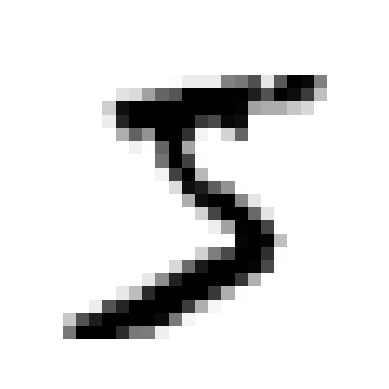

In [4]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28) # 28 by 28로 변경
    plt.imshow(image, cmap = 'binary') # binary : 0을 흰색, 255를 검은색으로 나타내는 흑백 컬러 맵 이용
    plt.axis('off')
    
some_digit = X[0]
plot_digit(some_digit)
plt.show()

In [5]:
# 실제 레이블 확인

y[0]

'5'

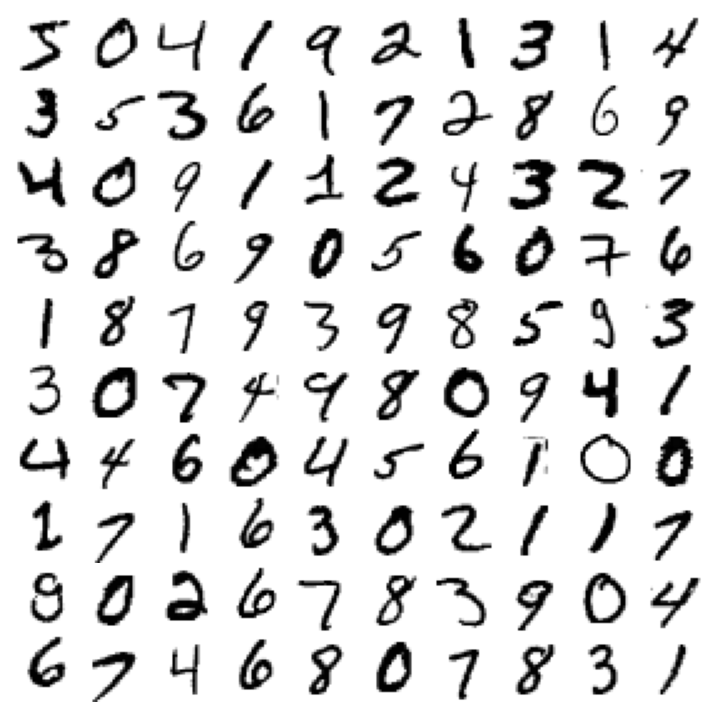

In [6]:
plt.figure(figsize = (9, 9))
for idx, image_data in enumerate(X[:100]):
    plt.subplot(10, 10, idx + 1)
    plot_digit(image_data)
    plt.axis('off')
    
plt.subplots_adjust(wspace = 0, hspace = 0);

In [7]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

# 이진 분류기 훈련

이진 분류기

- 5이다

- 5가 아니다

In [8]:
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

SGDClassifier클래스를 사용해 확률적 경사 하강법(SGD) 분류기

In [9]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state = 42)
sgd_clf.fit(X_train, y_train_5)

SGDClassifier(random_state=42)

In [10]:
sgd_clf.predict([some_digit]) # some_digit는 5이므로, X[1](0)은 5가 아니므로 False가 출력

array([ True])

# 성능 측정

## 교차 검정을 사용한 정확도 측정

In [11]:
# 이진 분류기 정확도 평가
# cross_val_score(estimator, x, y, cv)

from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_5, cv = 3, scoring = 'accuracy') # cv는 몇 겹 교차검증을 할지 정하는 파라미터

array([0.95035, 0.96035, 0.9604 ])

In [12]:
# 음성 클래스 => 5가 아님을 분류하는 더미 분류기 만들기

from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
# false가 출력 => true로 예측된 것이 없다
print(any(dummy_clf.predict(X_train)))

DummyClassifier()

False


In [13]:
cross_val_score(dummy_clf, X_train, y_train_5, cv = 3, scoring = 'accuracy')

array([0.90965, 0.90965, 0.90965])

이미지의 10% 정도만 숫자 5이므로 무조건 '5가 아니다'로 예측하면 정확히 맞출 확률이 90%이다

=> 분류에서 성능을 평가하는 더 좋은 방법은 오차 행렬(혼동 행렬)을 조사한다

## 오차 행렬

cross_val_predict() : k-폴드 교차 검증을 수행하지만 평가 점수를 반환하지 않고 각 텍스트 폴드에서 얻은 예측을 반환 

오차 행렬의 행 : 실제 클래스

오차 행렬의 열 : 예측한 클래스

In [14]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv = 3)

In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train_5, y_train_pred)

cm

array([[53892,   687],
       [ 1891,  3530]], dtype=int64)

[[TN, FP],

[FN, TP]]

TN : 사실이 아닌데 거짓으로 잘 판별

FP : 사실이 아닌데 맞다고 잘 못 판별

FN : 사실인데 거짓으로 잘 못 판별

TP : 사실인데 사실로 잘 판별

## 정밀도와 재현율

In [16]:
# 완벽한 분류기일 경우

y_train_perfect_predictions = y_train_5
confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]], dtype=int64)

정밀도 : 양성 예측의 정확도 => 맞다고 예측한 것 중 진짜 맞는 것

precision = TP / (TP + FP)

재현율 : 진짜 양성 비율 => 실제 맞는 것 중 사실로 맞춘 것

recall = TP / (FN + TP)

f1 = 2 * (정밀도 * 재현율) / (정밀도 + 재현율)

In [17]:
from sklearn.metrics import precision_score, recall_score

precision_score(y_train_5, y_train_pred)
recall_score(y_train_5, y_train_pred)

0.8370879772350012

0.6511713705958311

In [18]:
from sklearn.metrics import f1_score

f1_score(y_train_5, y_train_pred)

0.7325171197343846

f1 점수가 높으려면 재현율과 정밀도가 모두 높아야 한다

## 정밀도/재현율 트레이드오프

decision_function() 메서드를 호출하면 각 샘플의 점수를 얻을 수 있다

이 점수를 기반으로 원하는 임계값을 정해 예측을 만들 수 있다

임계값이 높을수록 재현율을 낮아지고 정밀도는 높아진다

In [19]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

threshold = 0
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([2164.22030239])

array([ True])

In [20]:
threshold = 3000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

In [21]:
# 적절한 임계값 정하기

y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv = 3, method = 'decision_function') # method = 'decision_function' :  예측 결정 점수를 반환

In [22]:
# 가능한 모든 임계값에 대해 정밀도와 재현율을 계산

from sklearn.metrics import precision_recall_curve
# 정밀도, 재현율, 임계값
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

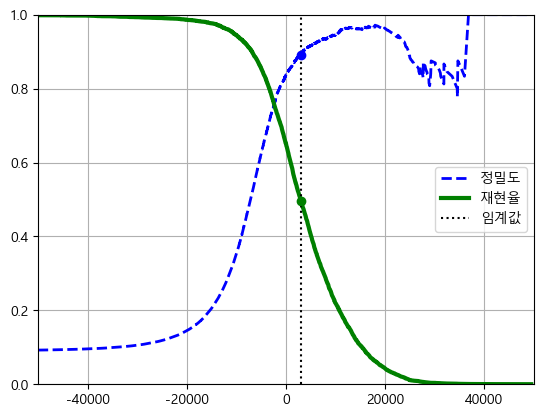

In [23]:
# 임계값이 30000일 때 그래프

plt.plot(thresholds, precisions[:-1], 'b--', label = '정밀도', linewidth = 2);
plt.plot(thresholds, recalls[:-1], 'g-', label = '재현율', linewidth = 3);
plt.vlines(threshold, 0, 1.0, 'k', 'dotted', label = '임계값');

idx = (thresholds >= threshold).argmax()  # 첫 번째 index ≥ threshold
plt.plot(thresholds[idx], precisions[idx], "bo")
plt.plot(thresholds[idx], recalls[idx], "go")
plt.axis([-50000, 50000, 0, 1])
plt.grid();
plt.legend(loc = 'center right');

정밀도는 90%, 재현율은 50% 정도이다

좋은 정밀도/재현율 트레이드오프를 선택하는 방법은 밑에 재현율에 대한 정밀도 곡선을 그리는 것이다

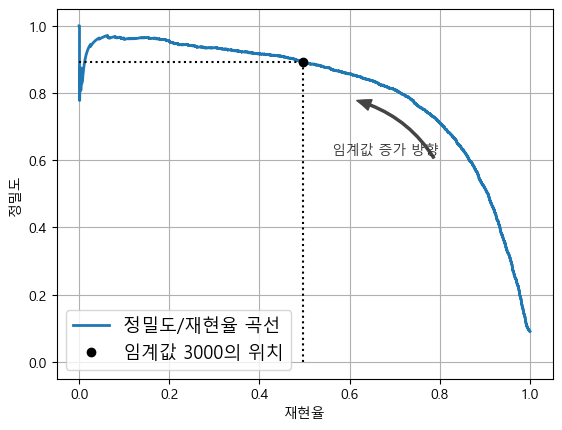

In [25]:
import matplotlib.patches as patches  # 추가 코드 – 구부러진 화살표를 그리기 위해서

plt.plot(recalls, precisions, linewidth = 2, label = '정밀도/재현율 곡선');


idx = (thresholds >= threshold).argmax()  # 첫 번째 index ≥ threshold
plt.plot([recalls[idx], recalls[idx]], [0, precisions[idx]], 'k:');
plt.plot([0.0, recalls[idx]], [precisions[idx], precisions[idx]], 'k:');
plt.plot([recalls[idx]], [precisions[idx]], 'ko', label = '임계값 3000의 위치');

plt.gca().add_patch(patches.FancyArrowPatch(
    (0.79, 0.60), (0.61, 0.78),
    connectionstyle = "arc3,rad=.2",
    arrowstyle = "Simple, tail_width=1.5, head_width=8, head_length=10",
    color = "#444444"));
plt.text(0.56, 0.62, "임계값 증가 방향", color="#333333")

plt.xlabel('재현율');
plt.ylabel('정밀도');
plt.grid();
plt.legend(loc = 'lower left', fontsize = 13);

In [26]:
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

3370.0194991439557

In [27]:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)

In [28]:
precision_score(y_train_5, y_train_pred_90)

recall_at_90_precision = recall_score(y_train_5, y_train_pred_90)
recall_at_90_precision

0.9000345901072293

0.4799852425751706

## ROC 곡선

ROC곡석 : 거짓 양성 비율에 대한 진짜 양성 비율

In [29]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

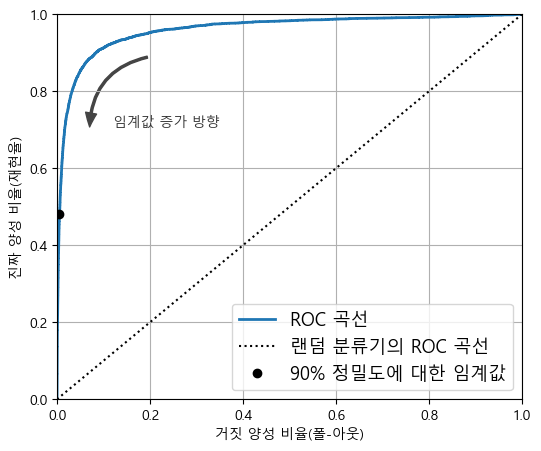

In [30]:
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.figure(figsize = (6, 5))  # 추가 코드
plt.plot(fpr, tpr, linewidth = 2, label = "ROC 곡선");
plt.plot([0, 1], [0, 1], 'k:', label = "랜덤 분류기의 ROC 곡선");
plt.plot([fpr_90], [tpr_90], "ko", label = "90% 정밀도에 대한 임계값");

plt.grid();
plt.xlabel('거짓 양성 비율(폴-아웃)');
plt.ylabel('진짜 양성 비율(재현율)');
plt.legend(loc = 'lower right', fontsize = 13);

plt.gca().add_patch(patches.FancyArrowPatch(
    (0.20, 0.89), (0.07, 0.70),
    connectionstyle="arc3,rad=.4",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"));
plt.text(0.12, 0.71, "임계값 증가 방향", color="#333333");
plt.axis([0, 1, 0, 1]);

In [31]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train_5, y_scores)

0.9604938554008616

RandomForestClassifier를 만들어 SGDClassifier의 PR 곡선과 F1 점수를 비교

In [32]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state = 42)

In [33]:
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv = 3, method = 'predict_proba')

In [34]:
y_probas_forest[:2]

array([[0.11, 0.89],
       [0.99, 0.01]])

In [35]:
y_scores_forest = y_probas_forest[:, 1]
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(y_train_5, y_scores_forest)

(0.0, 1.0, 0.0, 1.0)

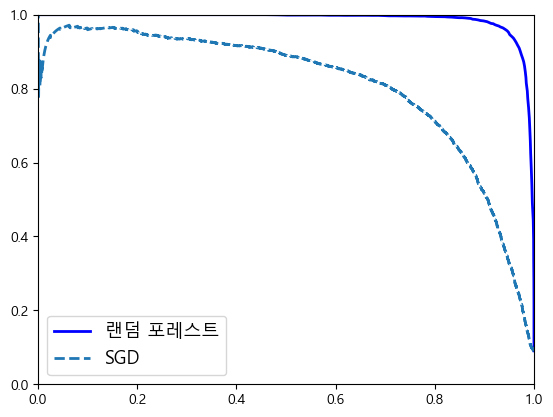

In [36]:
plt.plot(recalls_forest, precisions_forest, 'b-', linewidth = 2, label = '랜덤 포레스트')
plt.plot(recalls, precisions, '--', linewidth = 2, label = 'SGD')

plt.legend(loc = 'lower left', fontsize = 13)
plt.axis([0, 1, 0, 1])

In [37]:
y_train_pred_forest = y_probas_forest[:, 1] >= 0.5 # 양성 클래스 확률 >= 50%

f1_score(y_train_5, y_train_pred_forest)
roc_auc_score(y_train_5, y_scores_forest)

0.9274509803921569

0.9983436731328145

# 다중 분류